In [1]:
import os
import pandas as pd
import plotly.express as px
import sys
import numpy as np
from pathlib import Path
import math
import seaborn as sns
import matplotlib.pyplot as plt
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import utils.visualizations as visualizations

pd.set_option('display.max_columns', 100) # Setting pandas to display a N number of columns
pd.set_option('display.max_rows', 10) # Setting pandas to display a N number rows
pd.set_option('display.width', 1000) # Setting pandas dataframe display width to N

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrmorj/restaurant-recommendation-challenge")

print("Path to dataset files:", path)

d:\ITI Materials\Projects\restaurant-recommender-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\LAP X\.cache\kagglehub\datasets\mrmorj\restaurant-recommendation-challenge\versions\2


In [3]:
# Show all files and folders
dataframes = {}

# Show all files and load CSVs
for root, dirs, files in os.walk(path):
    print(f"\nDirectory: {root}")

    for d in dirs:
        print(f"  [DIR]  {d}")

    for f in files:
        print(f"  [FILE] {f}")

        if f.endswith(".csv"):
            csv_path = os.path.join(root, f)

            df_name = os.path.splitext(f)[0]
            dataframes[df_name] = pd.read_csv(csv_path)

            print(
                f"    -> Loaded DataFrame '{df_name}' "
                f"with shape {dataframes[df_name].shape}"
            )

print("\nLoaded DataFrames:")
print(list(dataframes.keys()))


Directory: C:\Users\LAP X\.cache\kagglehub\datasets\mrmorj\restaurant-recommendation-challenge\versions\2
  [FILE] orders.csv


C:\Users\LAP X\AppData\Local\Temp\ipykernel_17176\288914318.py:18: DtypeWarning: Columns (0: order_accepted_time, 1: driver_accepted_time, 2: picked_up_time, 3: delivered_time, 4: delivery_date) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[df_name] = pd.read_csv(csv_path)


    -> Loaded DataFrame 'orders' with shape (135303, 26)
  [FILE] SampleSubmission (1).csv
    -> Loaded DataFrame 'SampleSubmission (1)' with shape (1672000, 2)
  [FILE] test_customers.csv
    -> Loaded DataFrame 'test_customers' with shape (9768, 8)
  [FILE] test_full.csv


C:\Users\LAP X\AppData\Local\Temp\ipykernel_17176\288914318.py:18: DtypeWarning: Columns (0: customer_id, 1: gender, 2: created_at_x, 3: updated_at_x, 4: location_type, 5: vendor_category_en, 6: OpeningTime, 7: OpeningTime2, 8: is_akeed_delivering, 9: language, 10: sunday_from_time1, 11: sunday_to_time1, 12: sunday_from_time2, 13: sunday_to_time2, 14: monday_from_time1, 15: monday_to_time1, 16: monday_from_time2, 17: monday_to_time2, 18: tuesday_from_time1, 19: tuesday_to_time1, 20: tuesday_from_time2, 21: tuesday_to_time2, 22: wednesday_from_time1, 23: wednesday_to_time1, 24: wednesday_from_time2, 25: wednesday_to_time2, 26: thursday_from_time1, 27: thursday_to_time1, 28: thursday_from_time2, 29: thursday_to_time2, 30: friday_from_time1, 31: friday_to_time1, 32: friday_from_time2, 33: friday_to_time2, 34: saturday_from_time1, 35: saturday_to_time1, 36: saturday_from_time2, 37: saturday_to_time2, 38: primary_tags, 39: vendor_tag, 40: vendor_tag_name, 41: one_click_vendor, 42: created_a

    -> Loaded DataFrame 'test_full' with shape (1672000, 72)
  [FILE] test_locations.csv
    -> Loaded DataFrame 'test_locations' with shape (16720, 5)
  [FILE] train_customers.csv
    -> Loaded DataFrame 'train_customers' with shape (34674, 8)
  [FILE] train_full.csv


C:\Users\LAP X\AppData\Local\Temp\ipykernel_17176\288914318.py:18: DtypeWarning: Columns (0: gender) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[df_name] = pd.read_csv(csv_path)


    -> Loaded DataFrame 'train_full' with shape (5802400, 73)
  [FILE] train_locations.csv
    -> Loaded DataFrame 'train_locations' with shape (59503, 5)
  [FILE] VariableDefinitions.txt
  [FILE] vendors.csv
    -> Loaded DataFrame 'vendors' with shape (100, 59)

Loaded DataFrames:
['orders', 'SampleSubmission (1)', 'test_customers', 'test_full', 'test_locations', 'train_customers', 'train_full', 'train_locations', 'vendors']


In [4]:
display(dataframes["orders"].head(4))

,akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,vendor_rating,driver_rating,deliverydistance,preparationtime,delivery_time,order_accepted_time,driver_accepted_time,ready_for_pickup_time,picked_up_time,delivered_time,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID X LOC_NUM X VENDOR
0,163238.0,92PEE24,1.0,7.6,2,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,105,2019-08-01 05:30:16,0,NaN,92PEE24 X 0 X 105
1,163240.0,QS68UD8,1.0,8.7,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,294,2019-08-01 05:31:10,0,Work,QS68UD8 X 0 X 294
2,163241.0,MB7VY5F,2.0,14.4,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,83,2019-08-01 05:31:33,0,NaN,MB7VY5F X 0 X 83
3,163244.0,KDJ951Y,1.0,7.1,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,2019-08-01 04:03:00,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,90,2019-08-01 05:34:54,0,Home,KDJ951Y X 0 X 90


In [5]:
display(dataframes["vendors"].head(4))

,id,authentication_id,latitude,longitude,vendor_category_en,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,commission,is_akeed_delivering,discount_percentage,status,verified,rank,language,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,friday_from_time1,friday_to_time1,friday_from_time2,friday_to_time2,saturday_from_time1,saturday_to_time1,saturday_from_time2,saturday_to_time2,primary_tags,open_close_flags,vendor_tag,vendor_tag_name,one_click_vendor,country_id,city_id,created_at,updated_at,device_type,display_orders
0,4,118597.0,-0.588596,0.754434,Restaurants,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,"{""primary_tags"":""4""}",1.0,"2,4,5,8,91,22,12,24,16,23","Arabic,Breakfast,Burgers,Desserts,Free Deliver...",Y,1.0,1.0,2018-01-30 14:42:04,2020-04-07 15:12:43,3,1
1,13,118608.0,-0.471654,0.744470,Restaurants,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,Yes,0.0,1.0,1,11,EN,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,"{""primary_tags"":""7""}",1.0,"4,41,51,34,27,15,24,16,28","Breakfast,Cakes,Crepes,Italian,Pasta,Pizzas,Sa...",Y,1.0,1.0,2018-05-03 12:32:06,2020-04-05 20:46:03,3,1
2,20,118616.0,-0.407527,0.643681,Restaurants,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,Yes,0.0,1.0,1,1,EN,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,"{""primary_tags"":""71""}",1.0,"4,8,91,10","Breakfast,Desserts,Free Delivery,Indian",Y,1.0,1.0,2018-05-04 22:28:22,2020-04-07 16:35:55,3,1
3,23,118619.0,-0.585385,0.753811,Restaurants,2.0,0.0,5.0,1.0,10:59AM-10:30PM,-,16,0.0,Yes,0.0,1.0,1,11,EN,4.5,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,"{""primary_tags"":""46""}",1.0,"5,8,30,24","Burgers,Desserts,Fries,Salads",Y,1.0,1.0,2018-05-06 19:20:48,2020-04-02 00:56:17,3,1


In [6]:
display(dataframes["train_locations"].head(4))

,customer_id,location_number,location_type,latitude,longitude
0,02SFNJH,0,NaN,1.682392,-78.789737
1,02SFNJH,1,NaN,1.679137,0.766823
2,02SFNJH,2,NaN,-0.498648,0.661241
3,RU43CXC,0,Home,0.100853,0.438165


In [7]:
display(dataframes["train_customers"].head(4))

,akeed_customer_id,gender,dob,status,verified,language,created_at,updated_at
0,TCHWPBT,Male,NaN,1,1,EN,2018-02-07 19:16:23,2018-02-07 19:16:23
1,ZGFSYCZ,Male,NaN,1,1,EN,2018-02-09 12:04:42,2018-02-09 12:04:41
2,S2ALZFL,Male,NaN,0,1,EN,2018-03-14 18:31:43,2018-03-14 18:31:42
3,952DBJQ,Male,NaN,1,1,EN,2018-03-15 19:47:07,2018-03-15 19:47:07


In [8]:
display(dataframes["train_full"].head(4))

,customer_id,gender,status_x,verified_x,created_at_x,updated_at_x,location_number,location_type,latitude_x,longitude_x,id,authentication_id,latitude_y,longitude_y,vendor_category_en,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,commission,is_akeed_delivering,discount_percentage,status_y,verified_y,rank,language,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,friday_from_time1,friday_to_time1,friday_from_time2,friday_to_time2,saturday_from_time1,saturday_to_time1,saturday_from_time2,saturday_to_time2,primary_tags,open_close_flags,vendor_tag,vendor_tag_name,one_click_vendor,country_id,city_id,created_at_y,updated_at_y,device_type,display_orders,location_number_obj,id_obj,CID X LOC_NUM X VENDOR,target
0,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,4,118597.0,-0.5884,0.7544,Restaurants,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,"{""primary_tags"":""4""}",1.0,"2,4,5,8,91,22,12,24,16,23","Arabic,Breakfast,Burgers,Desserts,Free Deliver...",Y,1.0,1.0,2018-01-30 14:42:04,2020-04-07 15:12:43,3,1,0,4,TCHWPBT X 0 X 4,0
1,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,13,118608.0,-0.4717,0.7446,Restaurants,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,Yes,0.0,1.0,1,11,EN,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,"{""primary_tags"":""7""}",1.0,"4,41,51,34,27,15,24,16,28","Breakfast,Cakes,Crepes,Italian,Pasta,Pizzas,Sa...",Y,1.0,1.0,2018-05-03 12:32:06,2020-04-05 20:46:03,3,1,0,13,TCHWPBT X 0 X 13,0
2,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,20,118616.0,-0.4075,0.6436,Restaurants,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,Yes,0.0,1.0,1,1,EN,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,"{""primary_tags"":""71""}",1.0,"4,8,91,10","Breakfast,Desserts,Free Delivery,Indian",Y,1.0,1.0,2018-05-04 22:28:22,2020-04-07 16:35:55,3,1,0,20,TCHWPBT X 0 X 20,0
3,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,23,118619.0,-0.5854,0.7540,Restaurants,2.0,0.0,5.0,1.0,10:59AM-10:30PM,-,16,0.0,Yes,0.0,1.0,1,11,EN,4.5,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,"{""primary_tags"":""46""}",1.0,"5,8,30,24","Burgers,Desserts,Fries,Salads",Y,1.0,1.0,2018-05-06 19:20:48,2020-04-02 00:56:17,3,1,0,23,TCHWPBT X 0 X 23,0


In [9]:
orders_df = dataframes["orders"]
vendors_df = dataframes["vendors"]
train_locations_df = dataframes["train_locations"]
train_customers_df = dataframes["train_customers"]
train_full = dataframes["train_full"]

# 1. EDA

## Location Data

#### Vendors Locations

In [10]:
vendors_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 59 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    100 non-null    int64  
 1   authentication_id     100 non-null    float64
 2   latitude              100 non-null    float64
 3   longitude             100 non-null    float64
 4   vendor_category_en    100 non-null    str    
 5   vendor_category_id    100 non-null    float64
 6   delivery_charge       100 non-null    float64
 7   serving_distance      100 non-null    float64
 8   is_open               100 non-null    float64
 9   OpeningTime           91 non-null     str    
 10  OpeningTime2          91 non-null     str    
 11  prepration_time       100 non-null    int64  
 12  commission            85 non-null     float64
 13  is_akeed_delivering   100 non-null    str    
 14  discount_percentage   100 non-null    float64
 15  status                100 non-null 

In [11]:
visualizations.plot_geo_locations(vendors_df, "latitude", "longitude", "id", title="Vendors Locations")

#### Train Locations

In [12]:
train_locations_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59503 entries, 0 to 59502
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      59503 non-null  str    
 1   location_number  59503 non-null  int64  
 2   location_type    32294 non-null  str    
 3   latitude         59497 non-null  float64
 4   longitude        59497 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 2.3 MB


In [13]:
visualizations.plot_geo_locations(train_locations_df, "latitude", "longitude", "customer_id", title="Train locations")

In [14]:
#checking location_number vs location_type
(train_locations_df[~train_locations_df.location_type.isna()]['location_number'].astype('str')+'-'+train_locations_df[~train_locations_df.location_type.isna()]['location_type']).value_counts()

0-Home     12288
1-Home      4229
0-Work      3952
0-Other     3922
2-Home      1617
           ...  
25-Home        1
26-Home        1
27-Home        1
28-Home        1
29-Home        1
Name: count, Length: 62, dtype: int64

`0-Home` is much larger than the others suggests that the primary saved location (0) is usually the customer's home address.

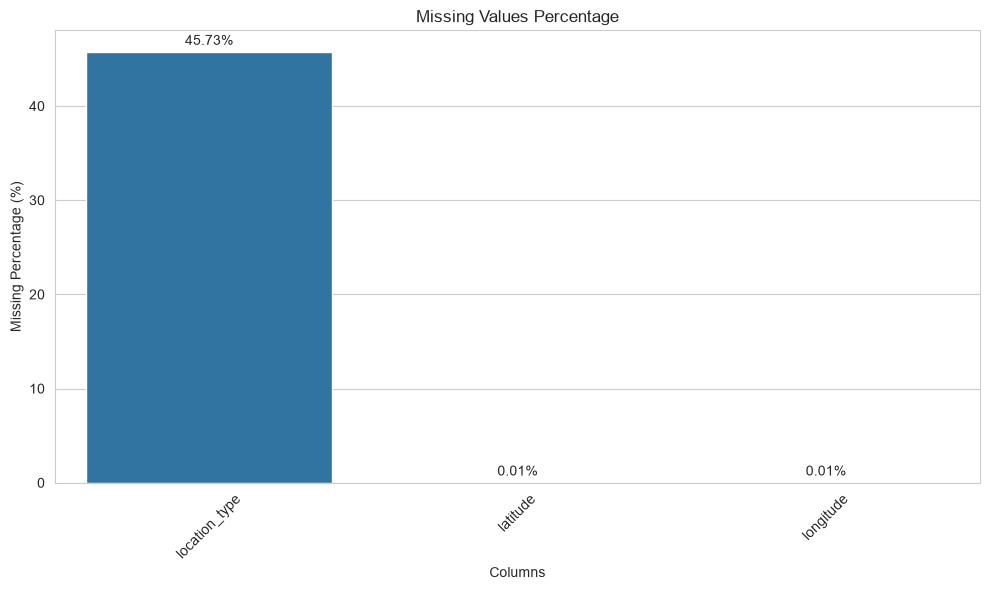

In [15]:
# check missing values within train locations dataset
visualizations.plot_missing_percentage(dataframes["train_locations"], figsize=(10, 6))

In [16]:
print(train_locations_df["location_type"].isna().mean())
print(train_locations_df["location_number"].isna().mean())

0.45727106196326234
0.0


In [17]:
# investigate the location types
train_locations_df["location_type"].unique()

<StringArray>
[nan, 'Home', 'Work', 'Other']
Length: 4, dtype: str

In [18]:
# distribution of location types
train_locations_df["location_type"].fillna("Unknown").value_counts(normalize=True) * 100

location_type
Unknown    45.727106
Home       33.112616
Work       10.824664
Other      10.335613
Name: proportion, dtype: float64

`location_type` contains 45% missing values in the locations dataset. The remaining records are distributed among three categories: Home, Work, and Other. Since the missing values represent a substantial portion of the data and may indicate customers who did not specify a location type, the feature should be retained and the missing values treated as a separate category (Unknown) rather than removed.

In [19]:
train_locations_df["location_type"] = train_locations_df["location_type"].fillna("Unknown")

print(train_locations_df["location_type"].isna().mean())

0.0


#### Distance between customers and vendors

Are customers concentrated around certain areas?

Are vendors spread evenly?

Are there vendors far away from customer clusters?

In [20]:
#defining function to mesaure distance bw 2 locations
#ref - https://www.adamsmith.haus/python/answers/how-to-find-the-distance-between-two-lat-long-coordinates-in-python
#radius of the Earth
def calculate_distance(df):
  R = 6373.0


  #coordinates
  lat1 = df.latitude_x.apply(math.radians)
  lon1 = df.longitude_x.apply(math.radians)
  lat2 = df.latitude_y.apply(math.radians)
  lon2 = df.longitude_y.apply(math.radians)

  #change in coordinates
  dlon = lon2 - lon1


  dlat = lat2 - lat1

  #Haversine formula
  a = ((dlat / 2)**2).apply(math.sin) + (lat1).apply(math.cos) * (lat2).apply(math.cos) * ((dlon / 2)**2).apply(math.sin)

  c = 2 * (a.apply(np.sqrt)/(1 - a).apply(np.sqrt)).apply(math.atan)
  distance = R * c
  return distance

In [21]:
train_location = train_locations_df[['latitude','longitude']].copy()
train_location['type'] = 'customers'

vendor_location = vendors_df[['latitude','longitude']].copy()
vendor_location['type'] = 'vendors'

locations = pd.concat(
    [train_location, vendor_location],
    ignore_index=True
)

fig = px.scatter_geo(
    locations,
    lat='latitude',
    lon='longitude',
    color="type"
)

fig.update_layout(
    title='Locations',
    title_x=0.5
)

fig.show()

In [22]:
# merge 2 datasets together to get the distance between the customer and the vendor
train = train_full.merge(orders_df,on='CID X LOC_NUM X VENDOR',how='inner')

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 132027 entries, 0 to 132026
Data columns (total 98 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   customer_id_x                   132027 non-null  str    
 1   gender                          104549 non-null  str    
 2   status_x                        132027 non-null  int64  
 3   verified_x                      132027 non-null  int64  
 4   created_at_x                    132027 non-null  str    
 5   updated_at_x                    132027 non-null  str    
 6   location_number                 132027 non-null  int64  
 7   location_type                   63113 non-null   str    
 8   latitude_x                      132022 non-null  float64
 9   longitude_x                     132022 non-null  float64
 10  id                              132027 non-null  int64  
 11  authentication_id               132027 non-null  float64
 12  latitude_y                 

<Axes: ylabel='Count'>

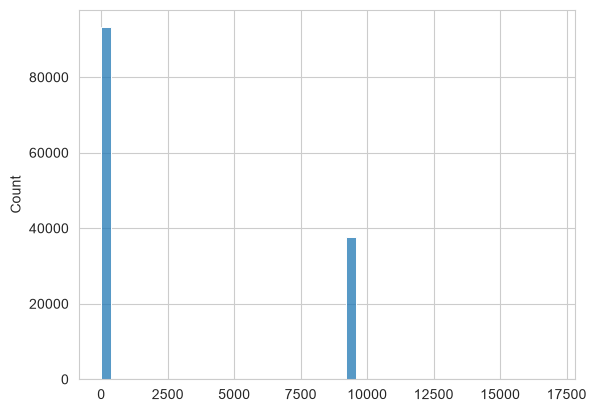

In [23]:
# calculate distances
distance = calculate_distance(train)

# plot distance distribution
sns.histplot(distance)

**The Massive Spike Near 0**: The tallest bar shows that the vast, overwhelming majority of orders (over 90,000 orders) are placed at restaurants located very close to the user (0 to a few kilometers away). This makes perfect sense—people prefer to order from local spots for faster delivery or easy pickup.

**the 9,500 Spike**: This spike represents corrupted or missing data

In [24]:
# inspect the delivery distance the vendors can deliver to
print('the maximum distance a vendor deliver is',str(np.max(train.serving_distance)))
percentiles = [5,10,11,12,15,20,30,50,75,100]
for i in percentiles:
  print(str(i)+' th percentile is', str(np.nanpercentile(distance,i)))

the maximum distance a vendor deliver is 15.0
5 th percentile is 8.663748299284842
10 th percentile is 14.564115659929197
11 th percentile is 15.850760176954099
12 th percentile is 17.047497503270332
15 th percentile is 20.631679268718077
20 th percentile is 27.21809194547721
30 th percentile is 42.568634952755836
50 th percentile is 80.56796484059669
75 th percentile is 9416.895226571361
100 th percentile is 16958.836767817513


1. The Normal Behavior (0 to 50th Percentile)
    The closest orders: Up to the 10th percentile, the distance is around 14.5 km.

    The middle point (50th Percentile): The median distance is 80.5 km.

2. The "Broken" Data (75th Percentile and up)
    The 75th Percentile: Suddenly jumps to 9,416 km.

    The 100th Percentile (Maximum): Goes all the way up to 16,958 km.

    Because the 75th percentile is already at 9,416 km, it means at least 25% of the entire dataset is corrupted by those extreme values.

`Note`: we will either drop the location data or cap it to specific threshold (ex: 50km)

## Customer's Profile

In [25]:
train_customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34674 entries, 0 to 34673
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   akeed_customer_id  34674 non-null  str    
 1   gender             22520 non-null  str    
 2   dob                3046 non-null   float64
 3   status             34674 non-null  int64  
 4   verified           34674 non-null  int64  
 5   language           21099 non-null  str    
 6   created_at         34674 non-null  str    
 7   updated_at         34674 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 2.1 MB


#### Trend of customer account creation over time.

When the platform started growing?

Peak acquisition months?

Growth/decline periods?

Seasonal patterns?

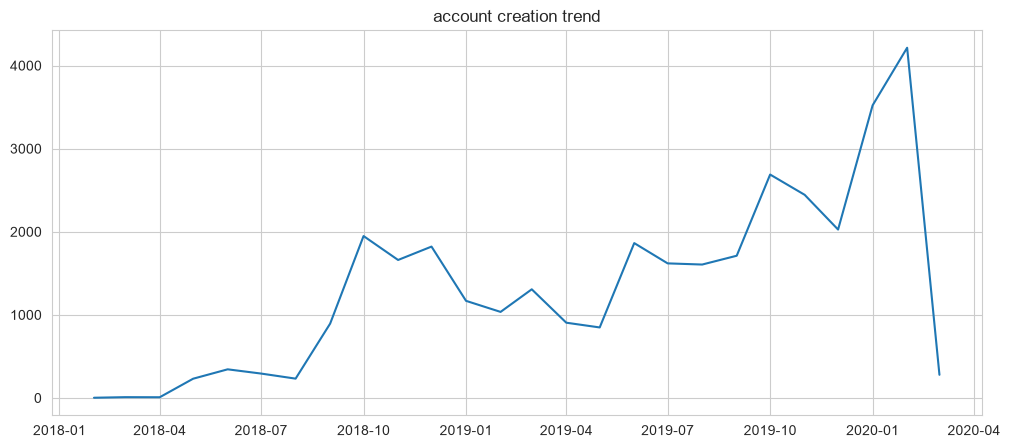

In [26]:
# trend of customer account creation over time.
plt.figure(figsize=(12,5))
plt.plot(pd.DataFrame(pd.to_datetime(train_customers_df['created_at'].apply(lambda x:x[:7]+'-01')).value_counts()).sort_index())
plt.title('account creation trend')
plt.show()

**Slow Start (Early 2018):** From January 2018 until around August 2018, the number of new accounts was almost stable and remained very low. This indicates that the platform was probably still in its early launch or testing stage.

**Steady Growth with Seasonal Peaks:** After late 2018, the platform started to attract more users and showed clear growth. There were noticeable spikes around October 2018, July 2019, and the highest peak around February 2020, where new accounts exceeded 4,000. These increases could be related to marketing campaigns, seasonal user activity, or promotional offers.

**The Sudden Drop (Early 2020):** At the end of the timeline, around March or April 2020, the number of new accounts dropped sharply back to almost zero. This sudden decrease may indicate a change in the platform activity, data collection period, or business operations.

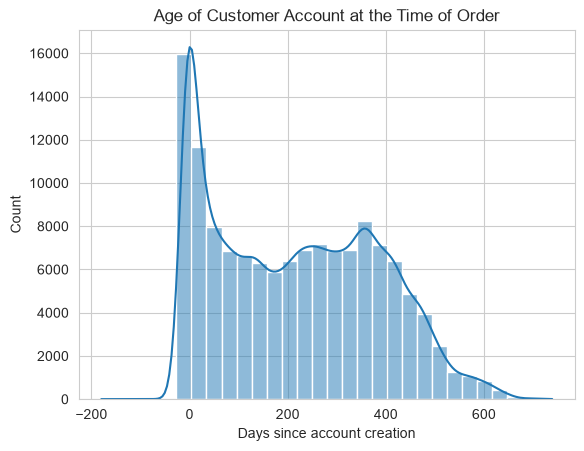

In [27]:
# Merge orders with customer creation dates
orders_with_cust = orders_df.merge(train_customers_df, left_on='customer_id', right_on='akeed_customer_id', how='inner')

# Convert to datetime (adjust column names based on your exact timestamp names, e.g., 'created_at')
orders_with_cust['order_date'] = pd.to_datetime(orders_with_cust['created_at_x']) # order time
orders_with_cust['account_created'] = pd.to_datetime(orders_with_cust['created_at_y']) # account creation time

# Calculate account age in days when they ordered
orders_with_cust['account_age_days'] = (orders_with_cust['order_date'] - orders_with_cust['account_created']).dt.days


sns.histplot(orders_with_cust['account_age_days'], bins=30, kde=True)
plt.title("Age of Customer Account at the Time of Order")
plt.xlabel("Days since account creation")
plt.show()

The model is optimized to handle fresh, history-light users.

**Note:** Since a large number of users created their accounts in late 2019 and early 2020, we have many new users who do not have enough order history to understand their preferences. This creates a **cold start problem**, where the recommendation system lacks sufficient user data to provide personalized recommendations.

To handle this issue, we can find similarities between new users and existing users with similar behaviors. Also, we can rely on popular local restaurants and highly-rated trending places to keep new users engaged until we collect enough interaction data and learn their personal tastes.

#### Trend of customer account update over time.

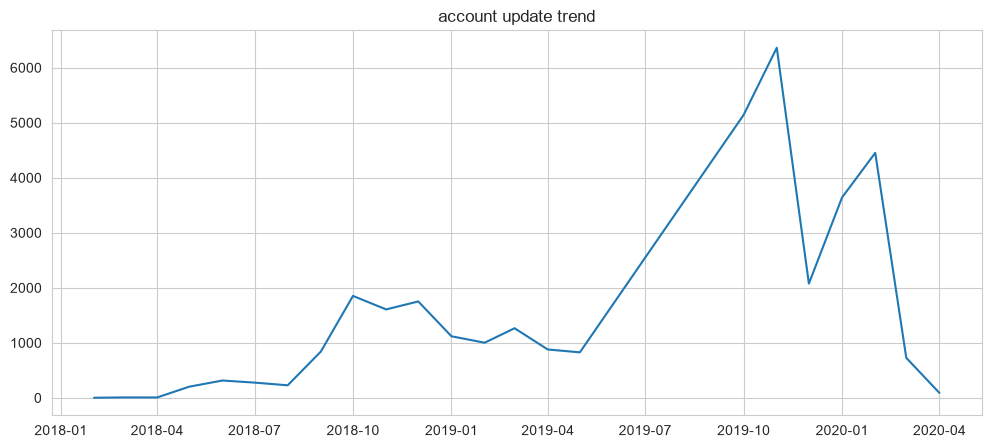

In [28]:
plt.figure(figsize=(12,5))
plt.plot(pd.DataFrame(pd.to_datetime(train_customers_df['updated_at'].apply(lambda x:x[:7]+'-01')).value_counts()).sort_index())
plt.title('account update trend')
plt.show()

Because users clearly update their profiles heavily during certain periods, many users have multiple addresses saved (e.g., Home vs. Work).

Our recommendation system shouldn't just look at a user's ID; it must look at their active address for that specific order. A user looking for a quick lunch at the office wants entirely different restaurant recommendations than when they are ordering a family dinner at home on the weekend.

#### Distribution of verified and status accounts

In [29]:
train_customers_df.verified.value_counts(normalize=True)

verified
1    0.956538
0    0.043462
Name: proportion, dtype: float64

In [30]:
train_customers_df.status.value_counts(normalize=True)

status
1    0.998991
0    0.001009
Name: proportion, dtype: float64

So we will remove `verified`, `status` feature as they don't add new information.

#### Languages spoken

In [31]:
train_customers_df.language.value_counts(normalize=True)

language
EN    1.0
Name: proportion, dtype: float64

removing language column as it has only one value.

#### Customer's gender distribution

In [32]:
train_customers_df.gender.value_counts(normalize=True)

gender
Male          0.791075
male          0.129396
Female        0.078197
Female        0.000577
Male          0.000400
Female        0.000089
Female        0.000089
?????         0.000089
Female        0.000044
              0.000044
Name: proportion, dtype: float64

we need to make the feature values correct.

#### Customer's Date of Birth

In [33]:
train_customers_df.dob.isna().sum() / len(train_customers_df)

np.float64(0.912153198361885)

This column is not useful as it contains many null values. so we need to remove it

### Vendors Characterstics

In [34]:
vendors_df.head()

,id,authentication_id,latitude,longitude,vendor_category_en,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,commission,is_akeed_delivering,discount_percentage,status,verified,rank,language,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,friday_from_time1,friday_to_time1,friday_from_time2,friday_to_time2,saturday_from_time1,saturday_to_time1,saturday_from_time2,saturday_to_time2,primary_tags,open_close_flags,vendor_tag,vendor_tag_name,one_click_vendor,country_id,city_id,created_at,updated_at,device_type,display_orders
0,4,118597.0,-0.588596,0.754434,Restaurants,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,"{""primary_tags"":""4""}",1.0,"2,4,5,8,91,22,12,24,16,23","Arabic,Breakfast,Burgers,Desserts,Free Deliver...",Y,1.0,1.0,2018-01-30 14:42:04,2020-04-07 15:12:43,3,1
1,13,118608.0,-0.471654,0.744470,Restaurants,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,Yes,0.0,1.0,1,11,EN,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,"{""primary_tags"":""7""}",1.0,"4,41,51,34,27,15,24,16,28","Breakfast,Cakes,Crepes,Italian,Pasta,Pizzas,Sa...",Y,1.0,1.0,2018-05-03 12:32:06,2020-04-05 20:46:03,3,1
2,20,118616.0,-0.407527,0.643681,Restaurants,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,Yes,0.0,1.0,1,1,EN,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,"{""primary_tags"":""71""}",1.0,"4,8,91,10","Breakfast,Desserts,Free Delivery,Indian",Y,1.0,1.0,2018-05-04 22:28:22,2020-04-07 16:35:55,3,1
3,23,118619.0,-0.585385,0.753811,Restaurants,2.0,0.0,5.0,1.0,10:59AM-10:30PM,-,16,0.0,Yes,0.0,1.0,1,11,EN,4.5,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,"{""primary_tags"":""46""}",1.0,"5,8,30,24","Burgers,Desserts,Fries,Salads",Y,1.0,1.0,2018-05-06 19:20:48,2020-04-02 00:56:17,3,1
4,28,118624.0,0.480602,0.552850,Restaurants,2.0,0.7,15.0,1.0,11:00AM-11:45PM,-,10,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,01:30:00,17:45:00,23:59:00,00:01:00,01:30:00,17:45:00,23:59:00,"{""primary_tags"":""32""}",1.0,5,Burgers,Y,1.0,1.0,2018-05-17 22:12:38,2020-04-05 15:57:41,3,1


In [35]:
# inspect vendor categories
display(vendors_df.vendor_category_en.value_counts(normalize=True))
display(vendors_df.vendor_category_id.value_counts(normalize=True))

vendor_category_en
Restaurants       0.88
Sweets & Bakes    0.12
Name: proportion, dtype: float64

vendor_category_id
2.0    0.89
3.0    0.11
Name: proportion, dtype: float64

For **hybrid  model** we will keep the `vendor_category_id` only and remove `vendor_category_en`.

while when using **Matrix Factorization** we will remove `both`

array([0. , 0.7])

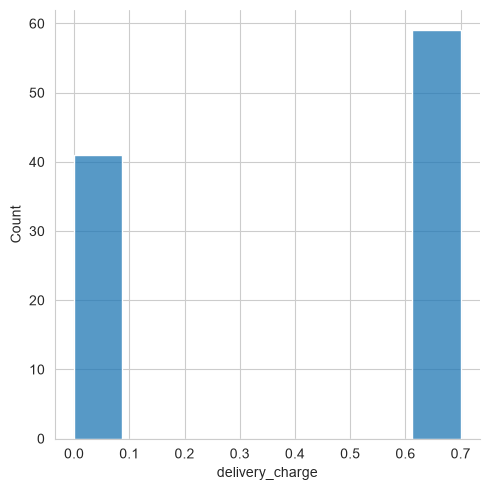

In [36]:
# inspect vendor's delivery charge
display(vendors_df.delivery_charge.unique())


# visualize distribution of delivery charge
sns.displot(vendors_df.delivery_charge)

In [37]:
# what is user's rating to vendors with different charge rate ?
vendors_df.groupby('delivery_charge')['vendor_rating'].mean()

delivery_charge
0.0    4.336585
0.7    4.359322
Name: vendor_rating, dtype: float64

- Vendors with free delivery (0.0) have average rating ≈ 4.34
- Vendors with 0.7 delivery charge have average rating ≈ 4.36

    so delivery charge does not seem to strongly affect ratings

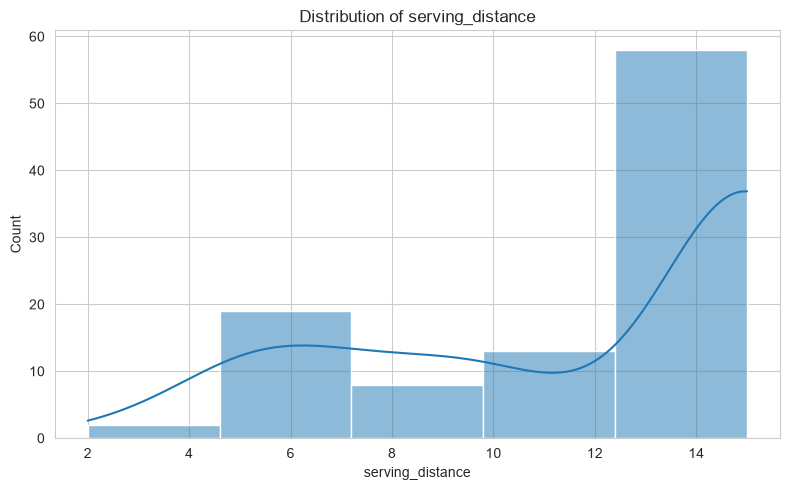

In [38]:
# distribution of vendor's serving distances
visualizations.plot_histogram(vendors_df, "serving_distance", bins=5, kde=True, figsize=(8, 5))

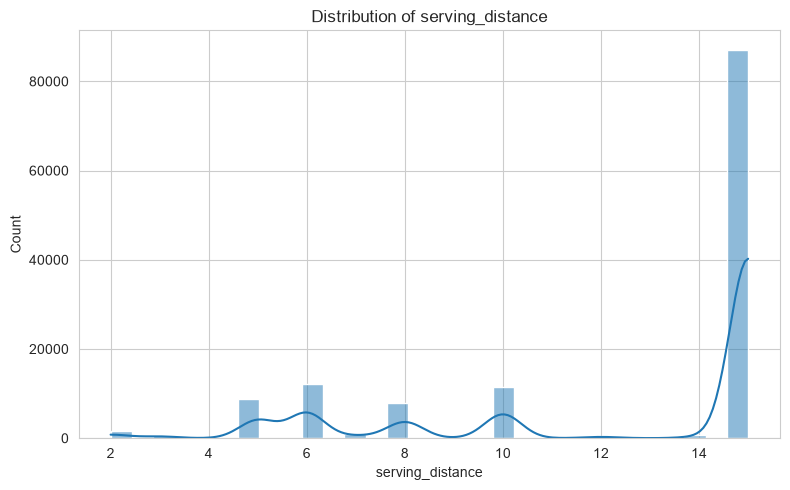

In [39]:
# number of orders made according to the serving distance
visualizations.plot_histogram(train, "serving_distance", bins=30, kde=True, figsize=(8, 5))

The vendors which covers more distance for delivery has most of the orders

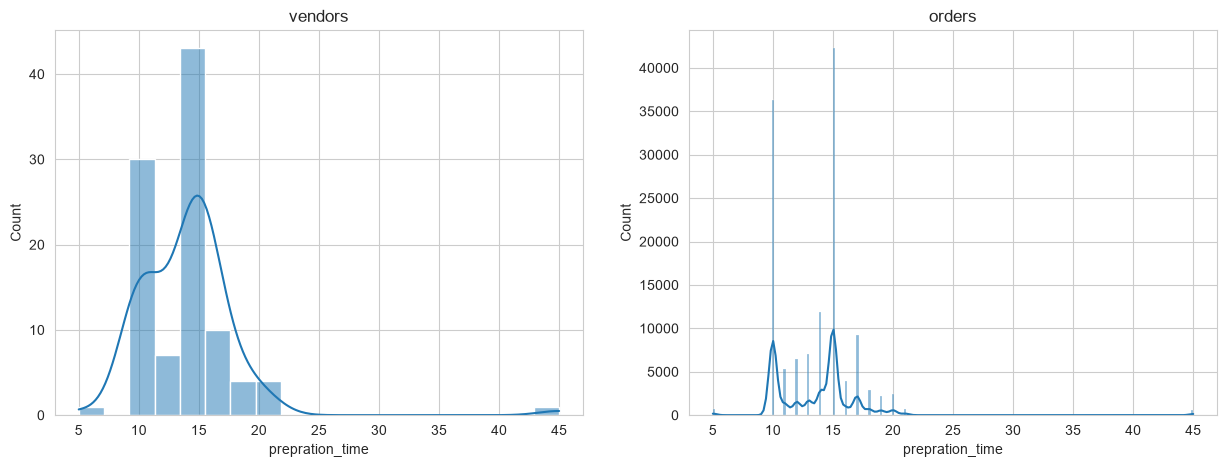

In [40]:
# people prefrences over preparation time
plt.figure(figsize=[15,5])
plt.subplot(1,2,1)
sns.histplot(vendors_df.prepration_time, kde=True)
plt.title('vendors')
plt.subplot(1,2,2)
sns.histplot(train.prepration_time, kde=True)
plt.title('orders')
plt.show()

In [60]:
# check commision, is_akeed_delivering, discount_percentage, status, verified, rank, language, one_click_vendor, country_id, city_id, device_type, display_orders attribute values
display(vendors_df.commission.value_counts())
display(vendors_df.is_akeed_delivering.value_counts())
display(vendors_df.discount_percentage.value_counts())
display(vendors_df.status.value_counts())
display(vendors_df.verified.value_counts())
display(vendors_df["rank"].value_counts())
display(vendors_df.language.value_counts())
display(vendors_df.one_click_vendor.value_counts())
display(vendors_df.country_id.value_counts())
display(vendors_df.city_id.value_counts())
display(vendors_df.device_type.value_counts())
display(vendors_df.display_orders.value_counts())

commission
0.0    85
Name: count, dtype: int64

is_akeed_delivering
Yes    100
Name: count, dtype: int64

discount_percentage
0.0     96
10.0     1
50.0     1
35.0     1
15.0     1
Name: count, dtype: int64

status
1.0    85
0.0    15
Name: count, dtype: int64

verified
1    88
0    12
Name: count, dtype: int64

...

one_click_vendor
Y    100
Name: count, dtype: int64

country_id
1.0    100
Name: count, dtype: int64

city_id
1.0    100
Name: count, dtype: int64

device_type
3    99
1     1
Name: count, dtype: int64

display_orders
1    100
Name: count, dtype: int64

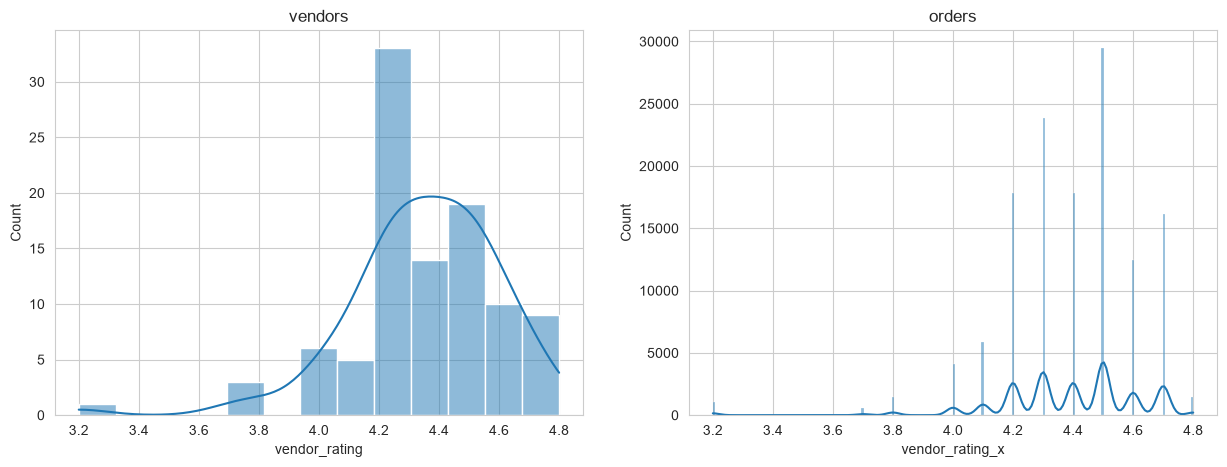

In [42]:
# people prefrence according to vendor's rating
plt.figure(figsize=[15,5])
plt.subplot(1,2,1)
sns.histplot(vendors_df.vendor_rating, kde=True)
plt.title('vendors')
plt.subplot(1,2,2)
sns.histplot(train.vendor_rating_x, kde=True)
plt.title('orders')
plt.show()

In [43]:
# total number of primary tags
vendors_df.primary_tags.value_counts()

primary_tags
{"primary_tags":"134"}     10
{"primary_tags":"2396"}     8
{"primary_tags":"8"}        5
{"primary_tags":"46"}       3
{"primary_tags":"32"}       3
                           ..
{"primary_tags":"1065"}     1
{"primary_tags":"1147"}     1
{"primary_tags":"1348"}     1
{"primary_tags":"1256"}     1
{"primary_tags":"15"}       1
Name: count, Length: 42, dtype: int64

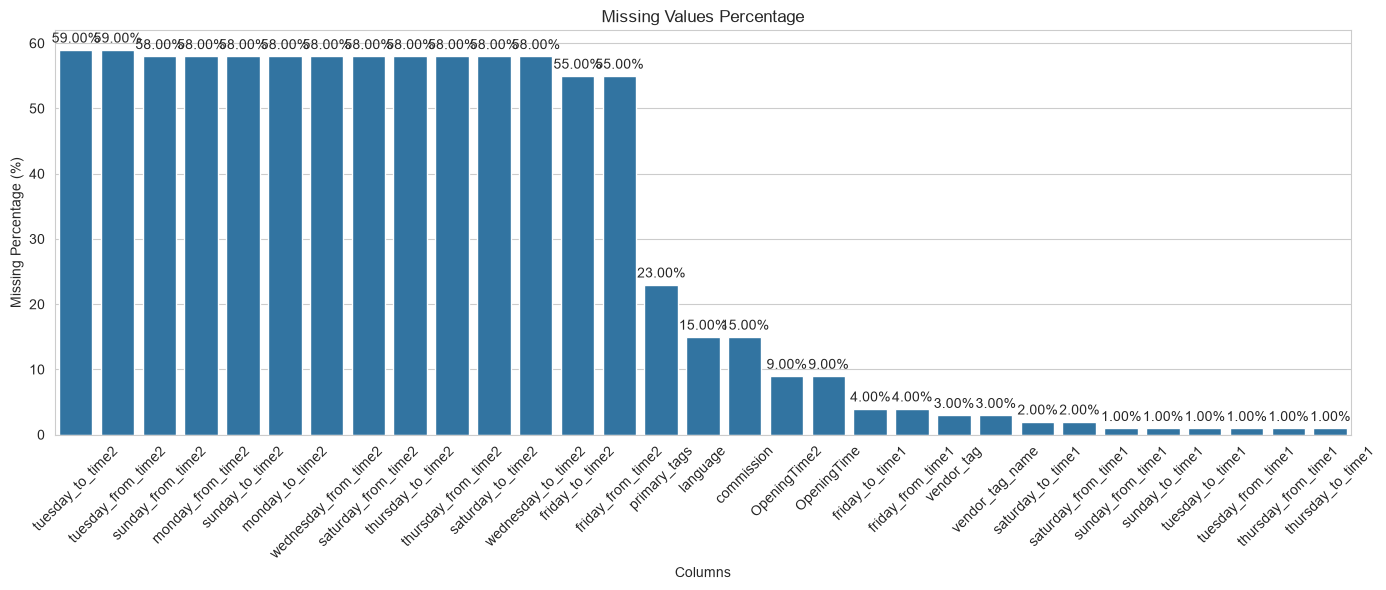

In [44]:
# check missing values
visualizations.plot_missing_percentage(vendors_df, figsize=(14, 6))

In [45]:
# fill missing values in vendor_tag_name with 0
vendors_df.vendor_tag_name = vendors_df.vendor_tag_name.fillna('0')

In [46]:
# create one-hot encoding for vendor_tag_name
categories_desc = []
for i in vendors_df.vendor_tag_name:
  a = i.split(',')
  for z in a:
    if z.lower().strip() not in categories_desc:
      categories_desc.append(z.lower().strip())

In [47]:
for category in categories_desc:
    vendors_df[category] = vendors_df.vendor_tag_name.apply(
        lambda x: 1 if category in x.lower() else 0
    )

# check shape
vendors_df.shape

(100, 127)

In [48]:
vendors_df.head()

,id,authentication_id,latitude,longitude,vendor_category_en,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,commission,is_akeed_delivering,discount_percentage,status,verified,rank,language,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,friday_from_time1,friday_to_time1,friday_from_time2,friday_to_time2,saturday_from_time1,saturday_to_time1,saturday_from_time2,saturday_to_time2,primary_tags,open_close_flags,...,mexican,american,milkshakes,asian,healthy food,japanese,sushi,mojitos,mandazi,omani,manakeesh,kids meal,donuts,fresh juices,ice creams,pancakes,waffles,hot dogs,dimsum,rice,sweets,steaks,pizza,mishkak,biryani,thali,vegetarian,pastry,seafood,0,chinese,thai,coffee,organic,smoothies,karak,rolls,hot chocolate,pastas,combos,bagels,churros,shuwa,frozen yoghurt,kushari,spanish latte,family meal,kebabs,cafe,fatayers
0,4,118597.0,-0.588596,0.754434,Restaurants,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,"{""primary_tags"":""4""}",1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,13,118608.0,-0.471654,0.744470,Restaurants,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,Yes,0.0,1.0,1,11,EN,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,"{""primary_tags"":""7""}",1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,20,118616.0,-0.407527,0.643681,Restaurants,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,Yes,0.0,1.0,1,1,EN,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,"{""primary_tags"":""71""}",1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,23,118619.0,-0.585385,0.753811,Restaurants,2.0,0.0,5.0,1.0,10:59AM-10:30PM,-,16,0.0,Yes,0.0,1.0,1,11,EN,4.5,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,"{""primary_tags"":""46""}",1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,28,118624.0,0.480602,0.552850,Restaurants,2.0,0.7,15.0,1.0,11:00AM-11:45PM,-,10,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,01:30:00,17:45:00,23:59:00,00:01:00,01:30:00,17:45:00,23:59:00,"{""primary_tags"":""32""}",1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
# count distribution of vendor's tag names
# split tags and explode them into rows
tags = vendors_df['vendor_tag_name'].dropna().str.split(',')

tag_counts = (
    tags
    .explode()
    .str.strip()
    .str.lower()
    .value_counts()
)

tag_counts

vendor_tag_name
desserts          44
sandwiches        42
burgers           40
salads            33
american          27
                  ..
frozen yoghurt     1
kushari            1
spanish latte      1
family meal        1
fatayers           1
Name: count, Length: 68, dtype: int64

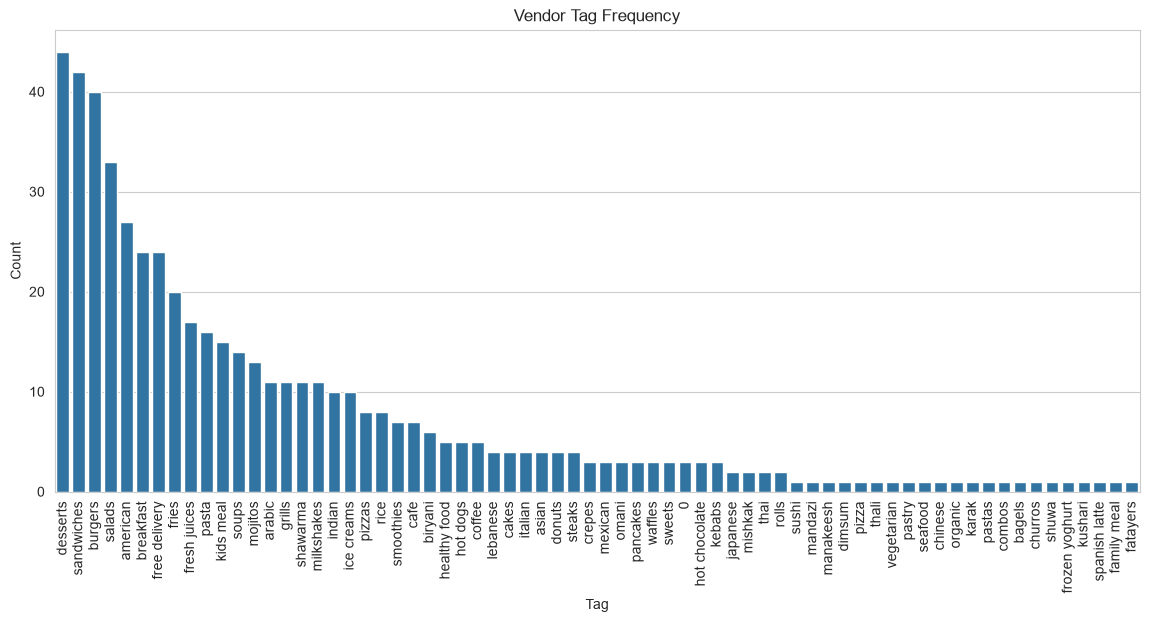

In [56]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=tag_counts.index,
    y=tag_counts.values
)

plt.title("Vendor Tag Frequency")
plt.xlabel("Tag")
plt.ylabel("Count")

plt.xticks(rotation=90)  # rotate labels so they don't overlap

plt.show()

In [58]:
# people tag names prefrences
train.vendor_tag_name = train.vendor_tag_name.fillna('0')

# train tags
train_tags = train['vendor_tag_name'].dropna().str.split(',')

train_tag_counts = (
    train_tags
    .explode()
    .str.strip()
    .str.lower()
    .value_counts()
)

train_tag_counts

vendor_tag_name
desserts         64520
burgers          57727
sandwiches       47750
free delivery    42009
salads           36290
                 ...  
chinese            691
shuwa              605
fatayers           594
seafood            585
spanish latte      582
Name: count, Length: 68, dtype: int64

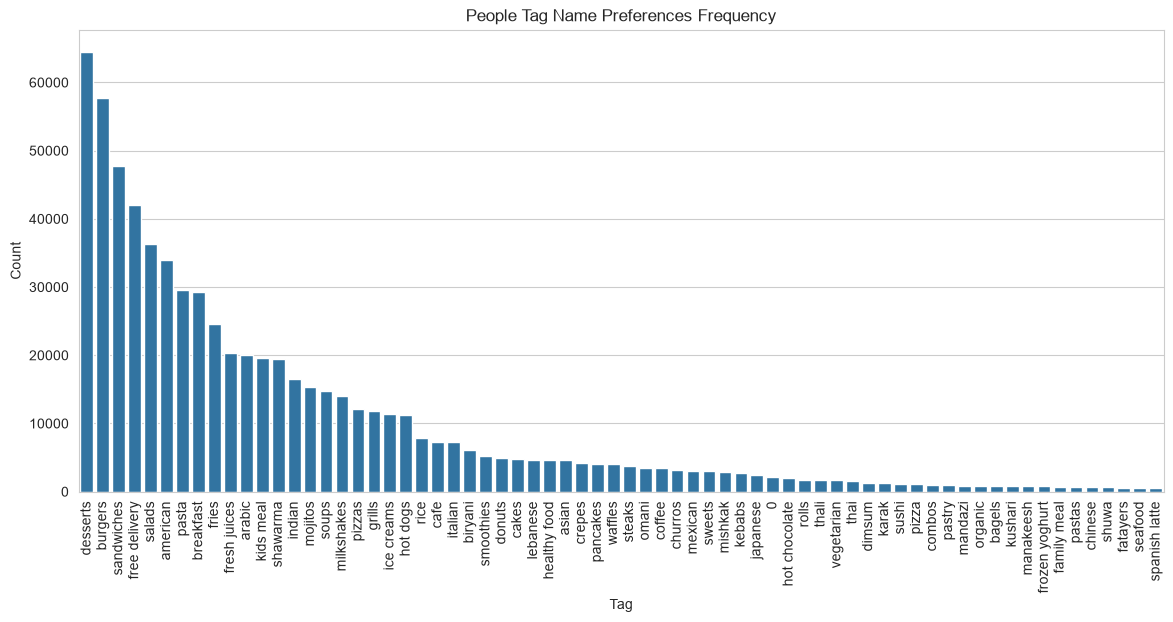

In [59]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=train_tag_counts.index,
    y=train_tag_counts.values
)

plt.title("People Tag Name Preferences Frequency")
plt.xlabel("Tag")
plt.ylabel("Count")

plt.xticks(rotation=90)  # rotate labels so they don't overlap

plt.show()

people prefer ordering dessert the most followed by burgers. Resturants are also serving foods according to demand.

### Data Cleaning

#### Completeness

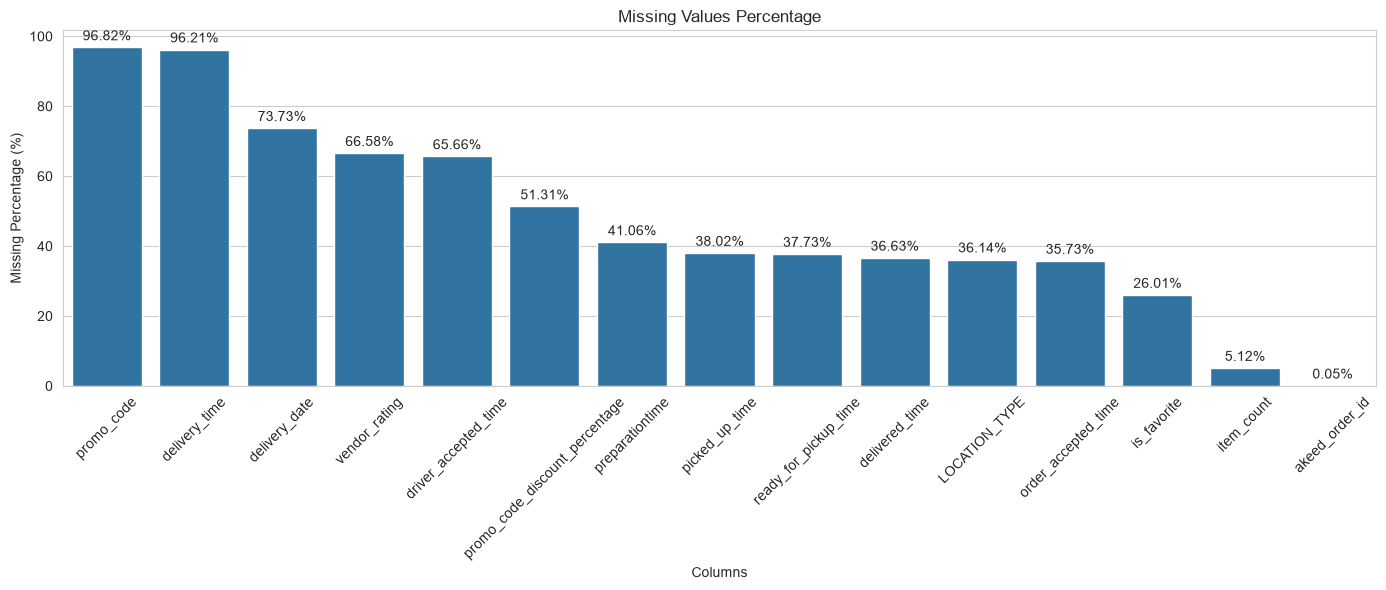

In [63]:
visualizations.plot_missing_percentage(orders_df, figsize=(14, 6))

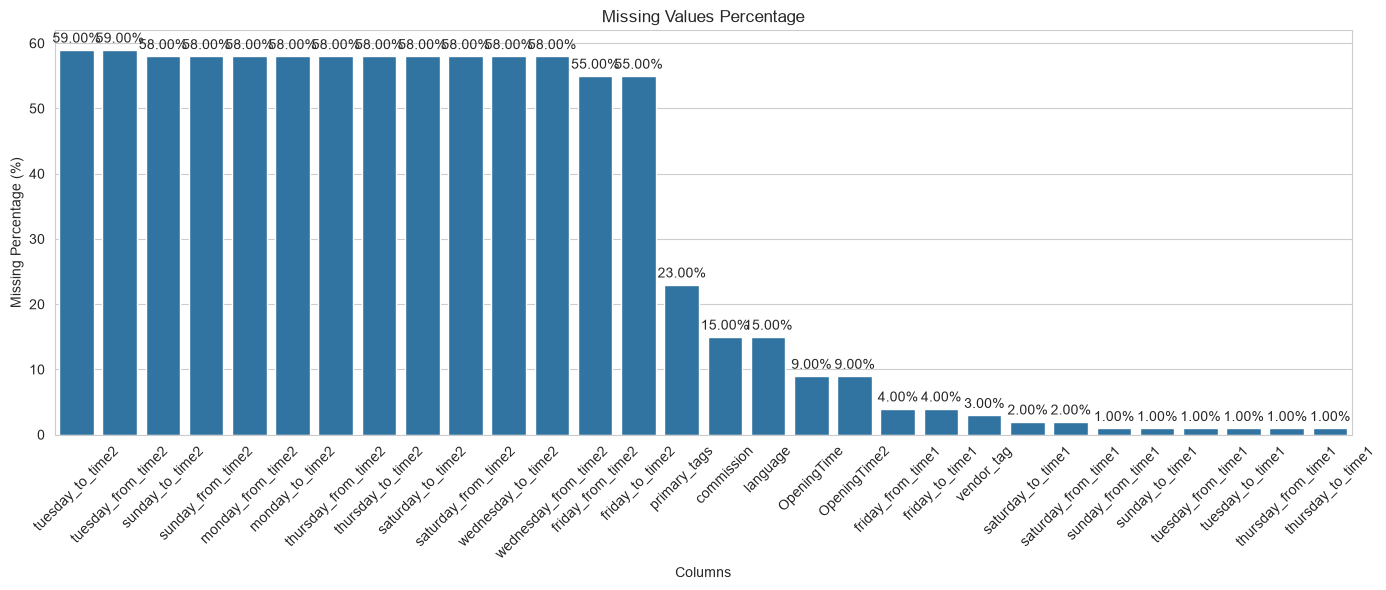

In [64]:
visualizations.plot_missing_percentage(vendors_df, figsize=(14, 6))

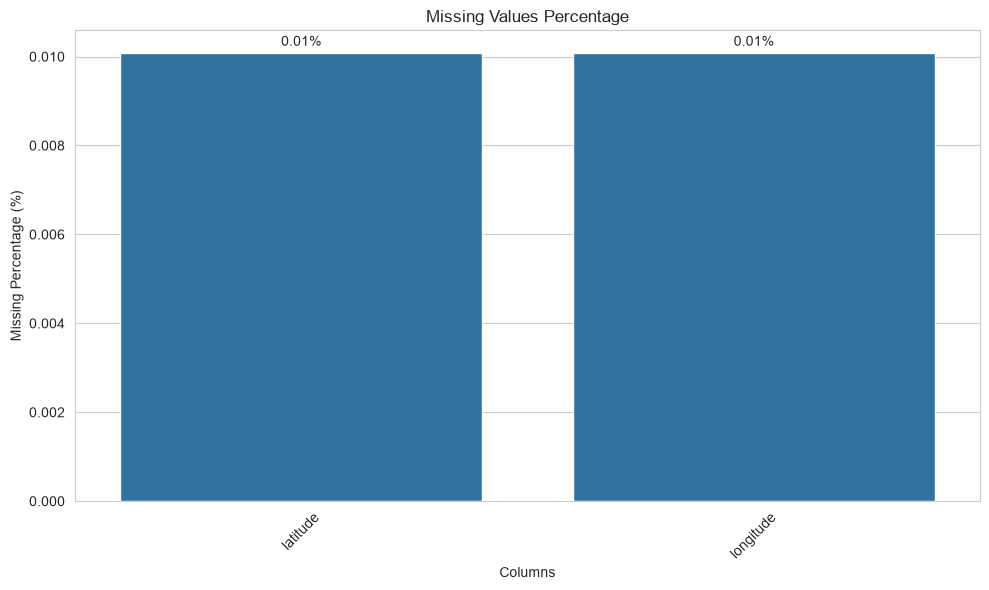

In [65]:
visualizations.plot_missing_percentage(train_locations_df, figsize=(10, 6))

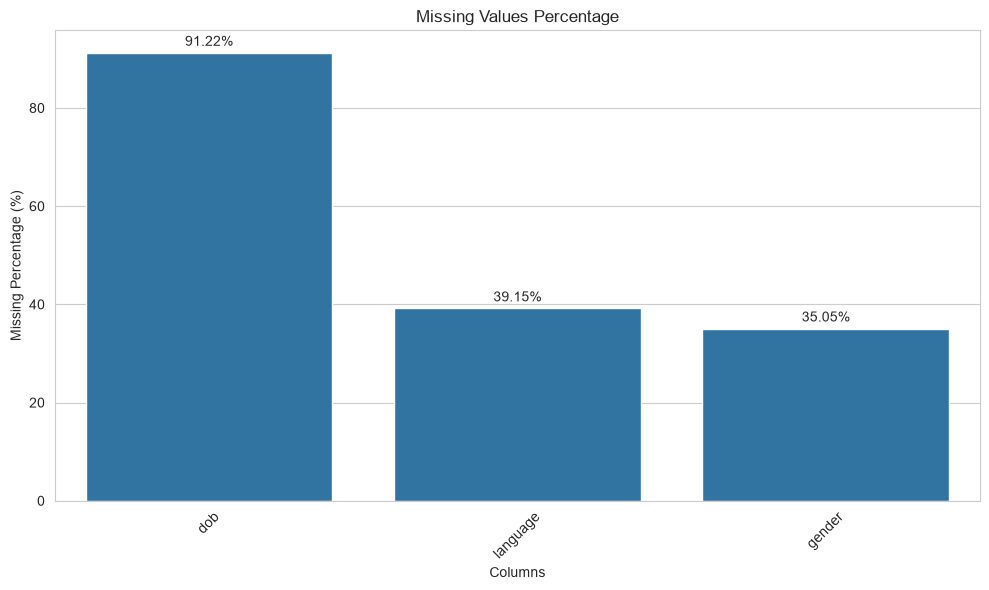

In [66]:
visualizations.plot_missing_percentage(train_customers_df, figsize=(10, 6))